# 03 · Text embeddings

Sentence-Transformer title embeddings projected to 256-d.

Requires `python scripts/build_embeddings.py`.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import src  # noqa: F401  (sets macOS OpenMP workaround before torch/faiss)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils.config import load_config
config = load_config()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.axisbelow": True})
SAME, DIFF = "#2a78d6", "#eb6834"  # fixed categorical slots 1 and 2

In [2]:
from src.embeddings.store import EmbeddingStore, embeddings_dir
store = EmbeddingStore.load(embeddings_dir(config))
meta = store.metadata
labels = pd.factorize(meta.label_group)[0]
print(store.manifest['text_model'], 'raw', store.text_raw.shape, '-> projected', store.text.shape)

sentence-transformers/all-MiniLM-L6-v2 raw (144, 384) -> projected (144, 256)


In [3]:
def same_vs_diff(emb, mask, labels):
    """Cosine similarities of same-group vs different-group pairs (both rows valid)."""
    idx = np.flatnonzero(mask)
    sims = emb[idx] @ emb[idx].T
    same = labels[idx][:, None] == labels[idx][None, :]
    iu = np.triu_indices(len(idx), k=1)
    return sims[iu][same[iu]], sims[iu][~same[iu]]

def plot_hist(same, diff, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    bins = np.linspace(min(diff.min(), same.min()), 1, 40)
    ax.hist(diff, bins=bins, density=True, alpha=0.6, color=DIFF, label=f"different product (n={len(diff)})")
    ax.hist(same, bins=bins, density=True, alpha=0.6, color=SAME, label=f"same product (n={len(same)})")
    ax.set_xlabel("cosine similarity"); ax.set_ylabel("density"); ax.set_title(title, loc="left")
    ax.legend(frameon=False); plt.show()

same-product mean 0.774  |  different-product mean 0.264


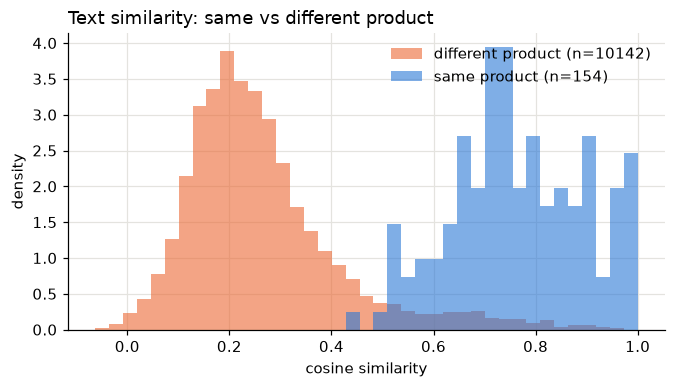

In [4]:
same, diff = same_vs_diff(store.text, store.text_mask, labels)
print(f'same-product mean {same.mean():.3f}  |  different-product mean {diff.mean():.3f}')
plot_hist(same, diff, 'Text similarity: same vs different product')

## Hardest text negatives
Different products whose titles look most alike: typically same brand and type, different colour.

In [5]:
sims = store.text @ store.text.T
iu = np.triu_indices(len(meta), 1)
neg = labels[iu[0]] != labels[iu[1]]
order = np.argsort(-sims[iu][neg])[:8]
a, b = iu[0][neg][order], iu[1][neg][order]
pd.DataFrame({'title A': meta.clean_title.values[a], 'title B': meta.clean_title.values[b],
              'text sim': sims[a, b].round(3), 'image sim': (store.image @ store.image.T)[a, b].round(3)})

,title A,title B,text sim,image sim
0,chronex analog wrist watch red 40mm,chronex analog wrist watch blue 40mm,0.964,0.755
1,chronex analog wrist watch blue 40mm,chronex analog wrist watch green 40mm,0.963,0.748
2,analog wrist watch chronex blue ch-wa112,analog wrist watch chronex green ch-wa119,0.961,0.854
3,chronex analog wrist watch red 40mm,chronex analog wrist watch green 40mm,0.960,0.870
4,sonicarc bluetooth headset blue 40h battery,sonicarc green bluetooth headset 40h battery,0.959,0.926
5,sonicarc bluetooth headset blue 40h battery,sonicarc green bluetooth headset 40h battery,0.959,0.823
6,urbankraft black t shirt size m,urbankraft yellow t shirt size m,0.932,0.829
7,sonicarc red over-ear headphones 40h battery,sonicarc blue over-ear headphones 40h battery,0.927,0.817


## Why combine modalities?
For each different-product pair, check whether image or text similarity is the more discriminative signal. The two error patterns differ, which is what fusion exploits.

In [6]:
img_s, txt_s = (store.image @ store.image.T)[iu], sims[iu]
same_pair = ~neg
print(f'corr(image sim, text sim) over all pairs: {np.corrcoef(img_s, txt_s)[0, 1]:.3f}')
for name, s in [('image', img_s), ('text', txt_s), ('0.6*img+0.4*txt', 0.6 * img_s + 0.4 * txt_s)]:
    gap = s[same_pair].mean() - s[neg].mean()
    print(f'{name:>16}: same-minus-different mean gap = {gap:.3f}')

corr(image sim, text sim) over all pairs: 0.501
           image: same-minus-different mean gap = 0.166
            text: same-minus-different mean gap = 0.510
 0.6*img+0.4*txt: same-minus-different mean gap = 0.303
